In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import micropip
await micropip.install("seaborn")
import seaborn as sns

df=pd.read_csv('car_data.csv')
df.head()


,Car_Name,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Selling_Price
0,Suzuki,2005,28.16,163819.0,Petrol,Dealer,Manual,1.0,19,6.43
1,Mercedes,2019,21.39,81396.0,Petrol,Individual,Manual,1.0,5,10.57
2,Audi,2012,21.13,112692.0,CNG,Dealer,Automatic,0.0,12,6.63
3,Ford,2015,15.51,62505.0,Diesel,Dealer,Automatic,1.0,9,5.26
4,Suzuki,2016,19.04,90896.0,CNG,Individual,Manual,0.0,8,7.95


In [3]:
df.columns = df.columns.str.strip()
df.columns

Index(['Car_Name', 'Year', 'Present_Price', 'Kms_Driven', 'Fuel_Type',
       'Seller_Type', 'Transmission', 'Owner', 'Car_Age', 'Selling_Price'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       1000 non-null   str    
 1   Year           1000 non-null   int64  
 2   Present_Price  1000 non-null   float64
 3   Kms_Driven     970 non-null    float64
 4   Fuel_Type      970 non-null    str    
 5   Seller_Type    1000 non-null   str    
 6   Transmission   1000 non-null   str    
 7   Owner          970 non-null    float64
 8   Car_Age        1000 non-null   int64  
 9   Selling_Price  1000 non-null   float64
dtypes: float64(4), int64(2), str(4)
memory usage: 62.6 KB


## Making copy df

In [33]:
df_lasso_copy=df.copy()
df_lasso_copy=df_lasso_copy.drop(columns=['Car_Name'])
df_lasso_copy.head()

,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Selling_Price
0,2005,28.16,163819.0,Petrol,Dealer,Manual,1.0,19,6.43
1,2019,21.39,81396.0,Petrol,Individual,Manual,1.0,5,10.57
2,2012,21.13,112692.0,CNG,Dealer,Automatic,0.0,12,6.63
3,2015,15.51,62505.0,Diesel,Dealer,Automatic,1.0,9,5.26
4,2016,19.04,90896.0,CNG,Individual,Manual,0.0,8,7.95


## Encoding

In [35]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df_lasso_copy['Fuel_Type']=le.fit_transform(df_lasso_copy['Fuel_Type'])
df_lasso_copy['Seller_Type']=le.fit_transform(df_lasso_copy['Seller_Type'])
df_lasso_copy['Transmission']=le.fit_transform(df_lasso_copy['Transmission'])

In [37]:
df_lasso_copy.dtypes

Year               int64
Present_Price    float64
Kms_Driven       float64
Fuel_Type          int32
Seller_Type        int32
Transmission       int32
Owner            float64
Car_Age            int64
Selling_Price    float64
dtype: object

## Heatmap and Corr

<Axes: >

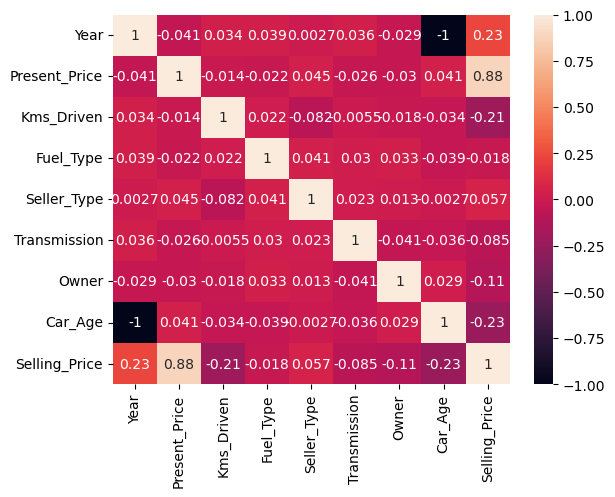

In [39]:
sns.heatmap(df_lasso_copy.corr(),annot=True)

## Observation
### Car_Age and year have almost same result so i'll drop one similarly fuel type also have very low correlation with respect to output feature

In [40]:
df_lasso_copy.drop(columns=['Car_Age','Fuel_Type'],inplace=True)
df_lasso_copy.head()


,Year,Present_Price,Kms_Driven,Seller_Type,Transmission,Owner,Selling_Price
0,2005,28.16,163819.0,0,1,1.0,6.43
1,2019,21.39,81396.0,1,1,1.0,10.57
2,2012,21.13,112692.0,0,0,0.0,6.63
3,2015,15.51,62505.0,0,0,1.0,5.26
4,2016,19.04,90896.0,1,1,0.0,7.95


<Axes: >

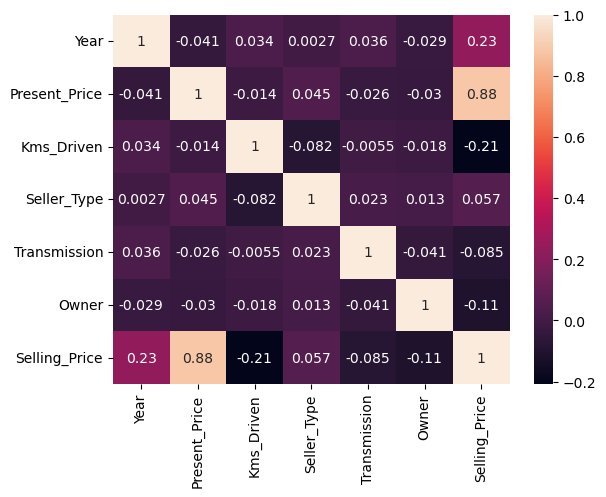

In [41]:
sns.heatmap(df_lasso_copy.corr(),annot=True)

## Independent and dependent features

In [42]:
X=df_lasso_copy.drop(columns=['Selling_Price'])
y=df_lasso_copy['Selling_Price']

## Handling Missing Values

In [43]:
X.isnull().sum()

Year              0
Present_Price     0
Kms_Driven       30
Seller_Type       0
Transmission      0
Owner            30
dtype: int64

In [44]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy='most_frequent')
X[['Owner']]=imputer.fit_transform(X[['Owner']])
X.isnull().sum()
X[['Kms_Driven']]=imputer.fit_transform(X[['Kms_Driven']])
X.isnull().sum()

Year             0
Present_Price    0
Kms_Driven       0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

## Train Test Split

In [45]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.25)

## Standard Scaling

In [46]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


## Lasso Regression

In [47]:
from sklearn.linear_model import Lasso
lassoreg=Lasso()
lassoreg.fit(X_train_scaled,y_train)
y_pred = lassoreg.predict(X_test_scaled)
## Calculating R2 and MAE,MSE,RMSE
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
score=r2_score(y_pred,y_test)
print(score)


0.6784014656010307


In [48]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print('RMSE :',rmse)
print('MAE:',mae)
print('MSE:', mse)

RMSE : 2.4435436994199984
MAE: 1.882252279766295
MSE: 5.970905810975172


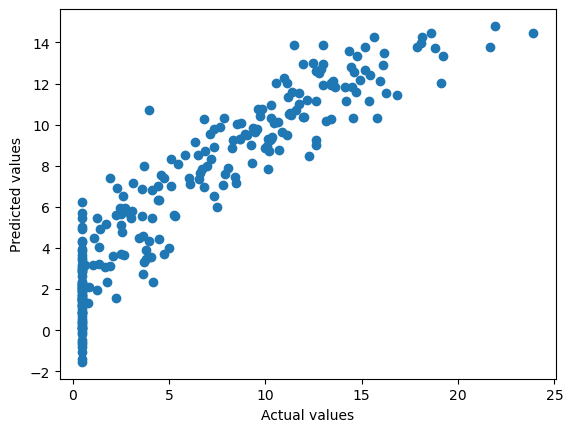

In [49]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.show()